# Simulation de la probabilité d'inondation — Rivière Coulantine

## Contexte

On modélise la probabilité qu'un fleuve déborde sur un horizon d'un an $t \in [0, 1]$.  
Chaque pluie survenant à l'instant $T_i$ apporte une intensité $I_i$ ; l'eau s'accumule et se résorbe exponentiellement.

| Composante | Modèle |
|---|---|
| Arrivée des pluies | Poisson inhomogène d'intensité $\lambda(t) = \lambda_0\bigl(1 + \alpha\sin(4\pi t)\bigr)$ |
| Intensité d'une pluie | Loi $\pi_I$ de densité $f_I(x) = \dfrac{c_I}{m + |x - x_0|^\eta},\ x \geq 0$ |
| Réponse hydrologique | $r(t) = e^{-vt}\,\mathbf{1}_{t \geq 0}$ |
| Hauteur d'eau | $H(t) = \displaystyle\sum_i I_i\,r(t - T_i)$ |
| Évènement inondation | $\bigl\{H_{\max} > h_0\bigr\}$ où $H_{\max} = \max_i H(T_i)$ |

**Objectif :** estimer $p^* = \mathbb{P}(H_{\max} > h_0)$ par Monte Carlo.

In [25]:
import numpy as np
import scipy.integrate as sci_int
import scipy.stats    as stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

rng = np.random.default_rng(seed=42)

## 1 · Paramètres du modèle

In [26]:
# ── Paramètres du modèle ──────────────────────────────────────────────────────
params = {
    "m"      : 2,    # hauteur du plateau central de f_I
    "x0"     : 3,    # mode de f_I
    "eta"    : 5,    # exposant de décroissance des queues
    "lambda0": 80,   # taux de base du processus de Poisson
    "alpha"  : 0.3,  # amplitude de la saisonnalité
    "v"      : 1,    # vitesse de résorption de l'eau
    "h0"     : 200,  # seuil d'inondation
}

---

## 2 · Simulation de la loi des intensités $\pi_I$

### 2.1 · Densité et constante de normalisation

La densité de l'intensité d'une pluie est définie par :

$$f_I(x) = \frac{c_I}{m + |x - x_0|^\eta}, \quad x \geq 0$$

La constante $c_I$ assure que $\int_0^{+\infty} f_I(x)\,dx = 1$ :

$$c_I = \left(\int_0^{+\infty} \frac{dx}{m + |x - x_0|^\eta}\right)^{-1}$$

Cette intégrale n'a pas de forme fermée simple — on la calcule numériquement.

In [27]:
def f_I_nn(x, m, x0, eta):
    """Noyau non normalisé de f_I : 1 / (m + |x - x0|^eta)."""
    return 1.0 / (m + np.abs(x - x0)**eta)

def calc_c_I(params):
    """Constante de normalisation c_I via intégration numérique sur [0, +∞)."""
    m, x0, eta = params["m"], params["x0"], params["eta"]
    val, _ = sci_int.quad(f_I_nn, 0, np.inf, args=(m, x0, eta))
    return 1.0 / val

def f_I(x, C_I, m, x0, eta):
    """Densité normalisée f_I(x) = c_I / (m + |x - x0|^eta)."""
    return C_I * f_I_nn(x, m, x0, eta)

# ── Calcul et vérification ────────────────────────────────────────────────────
C_I = calc_c_I(params)
m, x0, eta = params["m"], params["x0"], params["eta"]

verif, _ = sci_int.quad(f_I, 0, np.inf, args=(C_I, m, x0, eta))
print(f"Constante de normalisation  c_I = {C_I:.6f}")
print(f"Vérification : ∫ f_I dx        = {verif:.6f}  (doit être ≈ 1)")

Constante de normalisation  c_I = 0.816435
Vérification : ∫ f_I dx        = 1.000000  (doit être ≈ 1)


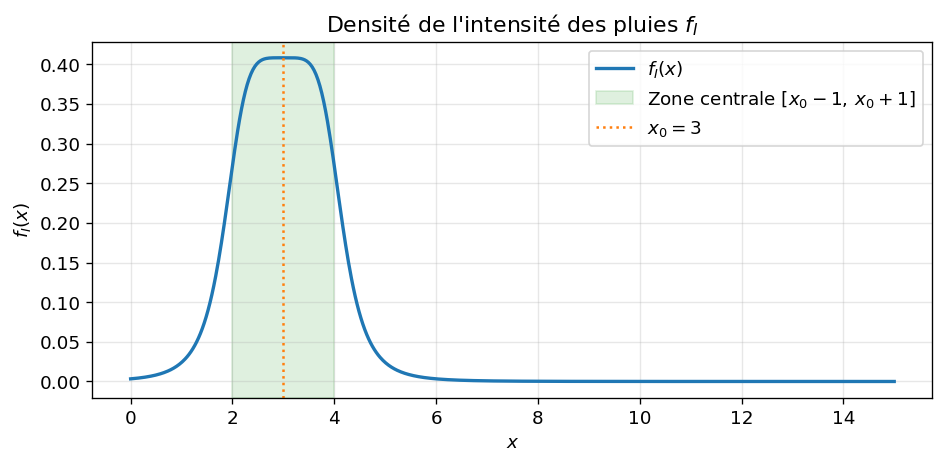

In [28]:
# ── Visualisation de f_I ──────────────────────────────────────────────────────
x_grid = np.linspace(0, 15, 800)
y_grid = f_I(x_grid, C_I, m, x0, eta)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_grid, y_grid, 'C0', lw=2, label=r"$f_I(x)$")
ax.axvspan(x0 - 1, x0 + 1, alpha=0.15, color='C2', label=r"Zone centrale $[x_0-1,\,x_0+1]$")
ax.axvline(x0, color='C1', ls=':', lw=1.5, label=f"$x_0 = {x0}$")
ax.set_xlabel("$x$"); ax.set_ylabel("$f_I(x)$")
ax.set_title(r"Densité de l'intensité des pluies $f_I$")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 2.2 · Décomposition en mélange

Pour simuler $f_I$ efficacement, on la décompose selon deux régions :

$$f_I(x) = p_c \cdot f_{\text{centrale}}(x) + (1 - p_c) \cdot f_{\text{queue}}(x)$$

où $p_c = \displaystyle\int_{x_0 - 1}^{x_0 + 1} f_I(x)\,dx$ est la masse de la **zone centrale**.

**Algorithme par mélange :**
1. Tirer $Z \sim \text{Bernoulli}(p_c)$
2. Si $Z = 1$ : simuler depuis $f_{\text{centrale}}$ par **rejet uniforme**
3. Si $Z = 0$ : simuler depuis $f_{\text{queue}}$ par **rejet Cauchy**

In [29]:
def masse_centrale(params, C_I):
    """p_c = ∫_{x0-1}^{x0+1} f_I(x) dx  (masse de la zone centrale)."""
    m, x0, eta = params["m"], params["x0"], params["eta"]
    val, _ = sci_int.quad(f_I, x0 - 1, x0 + 1, args=(C_I, m, x0, eta))
    return val

p_c = masse_centrale(params, C_I)
print(f"Masse zone centrale  p_c = {p_c:.6f}")
print(f"Masse des queues  1-p_c  = {1 - p_c:.6f}")

Masse zone centrale  p_c = 0.762313
Masse des queues  1-p_c  = 0.237687


### 2.3 · Zone centrale — rejet uniforme

Sur $[x_0 - 1,\, x_0 + 1]$, on a $|x - x_0| \leq 1$ donc $m + |x - x_0|^\eta \geq m$, d'où :

$$f_I(x) \leq \frac{c_I}{m} =: M_c, \quad \forall x \in [x_0 - 1,\, x_0 + 1]$$

**Algorithme de von Neumann :**
1. Proposer $X \sim \mathcal{U}([x_0 - 1,\, x_0 + 1])$
2. Proposer $U \sim \mathcal{U}([0,\, M_c])$
3. **Accepter** si $U \leq f_I(X)$, sinon recommencer

Ceci simule $f_I$ conditionnée à $[x_0-1, x_0+1]$, i.e. $f_{\text{centrale}}(x) = f_I(x)/p_c$.  
Le taux d'acceptation est $p_c \cdot m / c_I = p_c \cdot m / c_I$.

In [30]:
def sim_centrale(n, C_I, params, rng):
    """
    Simule n valeurs depuis f_I restreinte à [x0-1, x0+1]
    par rejet uniforme (von Neumann).
    Retourne un tableau de forme (n,).
    """
    m, x0, eta = params["m"], params["x0"], params["eta"]
    borne_inf, borne_sup = x0 - 1, x0 + 1
    M_c = C_I / m  # borne supérieure de f_I sur [x0-1, x0+1]

    result   = np.empty(n)
    acceptes = 0
    while acceptes < n:
        batch = max(2 * (n - acceptes), 100)
        X = rng.uniform(borne_inf, borne_sup, batch)
        U = rng.uniform(0, M_c, batch)
        ok = U <= f_I(X, C_I, m, x0, eta)
        nouveaux = X[ok]
        fin = min(acceptes + len(nouveaux), n)
        result[acceptes:fin] = nouveaux[:fin - acceptes]
        acceptes = fin
    return result

### 2.4 · Queue de distribution — rejet Cauchy

Sur $[0, +\infty) \setminus [x_0-1, x_0+1]$, la densité $f_I$ a des queues lourdes.  
On choisit comme densité instrumentale une **loi de Cauchy** $g(x) = \mathcal{C}(x_0,\, \sqrt{m})$, tronquée hors de $[x_0-1, x_0+1]$ et sur $x \geq 0$.

**Pourquoi Cauchy ?** Les queues de $f_I$ décroissent en $|x - x_0|^{-\eta}$, celles de la Cauchy en $|x - x_0|^{-1}$. Puisque $\eta = 5 > 1$, la Cauchy est plus lourde, ce qui garantit que le ratio $f_I / g$ est borné.

**Borne sur le ratio :** on choisit l'échelle $\sqrt{m}$ pour que :
$$\frac{f_I(x)}{g(x)} \leq \sqrt{m} =: M_q, \quad \forall x \in \text{queue}$$

**Algorithme :**
1. Proposer $X \sim \mathcal{C}(x_0, \sqrt{m})$ conditionné à être dans la queue
2. Proposer $U \sim \mathcal{U}([0,\, M_q])$
3. **Accepter** si $U \leq f_I(X) / g(X)$

In [31]:
def cauchy_queue(n, x0, scale, rng):
    """
    Simule n valeurs d'une Cauchy(x0, scale)
    restreinte à [0, +∞) \ [x0-1, x0+1]  (la «queue»).
    """
    result   = np.empty(n)
    acceptes = 0
    while acceptes < n:
        batch = max(4 * (n - acceptes), 100)
        X = rng.standard_cauchy(batch) * scale + x0
        # On garde uniquement les valeurs dans la queue
        dans_queue = X[(X >= 0) & ((X < x0 - 1) | (X > x0 + 1))]
        fin = min(acceptes + len(dans_queue), n)
        result[acceptes:fin] = dans_queue[:fin - acceptes]
        acceptes = fin
    return result


def sim_queue(n, C_I, params, rng):
    """
    Simule n valeurs depuis f_I restreinte à la queue
    par rejet avec instrumentale Cauchy(x0, sqrt(m)).
    Retourne un tableau de forme (n,).
    """
    m, x0, eta = params["m"], params["x0"], params["eta"]
    scale = np.sqrt(m)      # échelle de la Cauchy instrumentale
    M_q   = scale           # borne supérieure de f_I / g

    result   = np.empty(n)
    acceptes = 0
    while acceptes < n:
        batch = max(2 * (n - acceptes), 100)
        X = cauchy_queue(batch, x0, scale, rng)
        U = rng.uniform(0, M_q, len(X))
        # g(x) = pdf de Cauchy(x0, scale) — scipy utilise loc/scale
        ratio = f_I(X, C_I, m, x0, eta) / stats.cauchy.pdf(X, loc=x0, scale=scale)
        ok    = U <= ratio
        nouveaux = X[ok]
        fin = min(acceptes + len(nouveaux), n)
        result[acceptes:fin] = nouveaux[:fin - acceptes]
        acceptes = fin
    return result

<>:4: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:4: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
C:\Users\diaba\AppData\Local\Temp\ipykernel_12256\223751904.py:4: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
  restreinte à [0, +∞) \ [x0-1, x0+1]  (la «queue»).


### 2.5 · Fonction `rintensite` — assemblage par mélange

In [32]:
def rintensite(n, params, rng):
    """
    Simule n réalisations indépendantes de la loi π_I.

    Algorithme par mélange :
      - Z_i ~ Bernoulli(p_c)
      - si Z_i = 1 : simulation centrale (rejet uniforme)
      - si Z_i = 0 : simulation queue    (rejet Cauchy)

    Args:
        n      : nombre de valeurs à simuler
        params : dictionnaire des paramètres du modèle
        rng    : générateur numpy

    Returns:
        np.ndarray de forme (n,)
    """
    C_I = calc_c_I(params)
    p_c = masse_centrale(params, C_I)

    Z  = rng.random(n) <= p_c   # True → zone centrale
    K  = Z.sum()                # nombre de points en zone centrale

    result = np.empty(n)
    if K > 0:
        result[Z]  = sim_centrale(K,     C_I, params, rng)
    if K < n:
        result[~Z] = sim_queue(n - K,    C_I, params, rng)
    return result

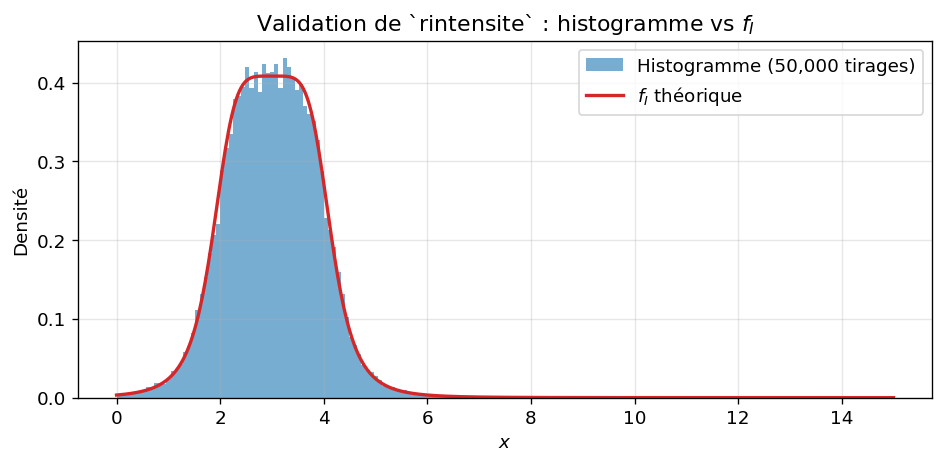

In [33]:
# ── Vérification : histogramme vs densité théorique ───────────────────────────
n_test = 50_000
echantillon = rintensite(n_test, params, rng)

x_grid = np.linspace(0, 15, 500)
C_I    = calc_c_I(params)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(echantillon, bins=150, density=True, color='C0', alpha=0.6, label=f"Histogramme ({n_test:,} tirages)")
ax.plot(x_grid, f_I(x_grid, C_I, m, x0, eta), 'C3', lw=2, label=r"$f_I$ théorique")
ax.set_xlabel("$x$"); ax.set_ylabel("Densité")
ax.set_title(r"Validation de `rintensite` : histogramme vs $f_I$")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---

## 3 · Processus de Poisson inhomogène — dates des pluies

### 3.1 · Intensité saisonnière

Les pluies arrivent selon un **processus de Poisson inhomogène** d'intensité :

$$\lambda(t) = \lambda_0\bigl(1 + \alpha\sin(4\pi t)\bigr), \quad t \in [0, 1]$$

Le nombre moyen de pluies par an est $\Lambda = \int_0^1 \lambda(t)\,dt = \lambda_0$ (car $\int_0^1 \sin(4\pi t)\,dt = 0$).

### 3.2 · Méthode de thinning (Lewis-Shedler)

On exploite la borne $\lambda(t) \leq \lambda_0(1 + \alpha) < 2\lambda_0 =: \Lambda_{\max}$.

**Algorithme :**
1. Générer les dates d'un processus de Poisson **homogène** de taux $\Lambda_{\max} = 2\lambda_0$  
   (inter-arrivées $\sim \mathcal{E}(\Lambda_{\max})$)
2. Conserver chaque date $T_i$ avec probabilité $\dfrac{\lambda(T_i)}{\Lambda_{\max}}$ (**thinning**)

Les dates conservées forment un processus de Poisson inhomogène d'intensité $\lambda(t)$.

In [34]:
def lambda_t(t, lambda0, alpha):
    """Intensité du processus de Poisson : λ(t) = λ0 (1 + α sin(4πt))."""
    return lambda0 * (1 + alpha * np.sin(4 * np.pi * t))


def sim_pluies(params, rng):
    """
    Simule les dates d'arrivée des pluies sur [0, 1]
    par la méthode de thinning (Lewis-Shedler).

    Returns:
        np.ndarray des dates T_i dans [0, 1] (peut être vide)
    """
    lambda0, alpha = params["lambda0"], params["alpha"]
    Lambda_max = 2 * lambda0  # borne supérieure de λ(t)

    dates = []
    t = 0.0
    while True:
        t += rng.exponential(1.0 / Lambda_max)   # inter-arrivée homogène
        if t > 1.0:
            break
        # thinning : garder avec prob λ(t) / Λ_max
        if rng.random() <= lambda_t(t, lambda0, alpha) / Lambda_max:
            dates.append(t)
    return np.array(dates)

λ0 (valeur théorique) = 80
Nombre moyen simulé   = 79.92
Variance simulée      = 79.25  (doit ≈ λ0 = 80)


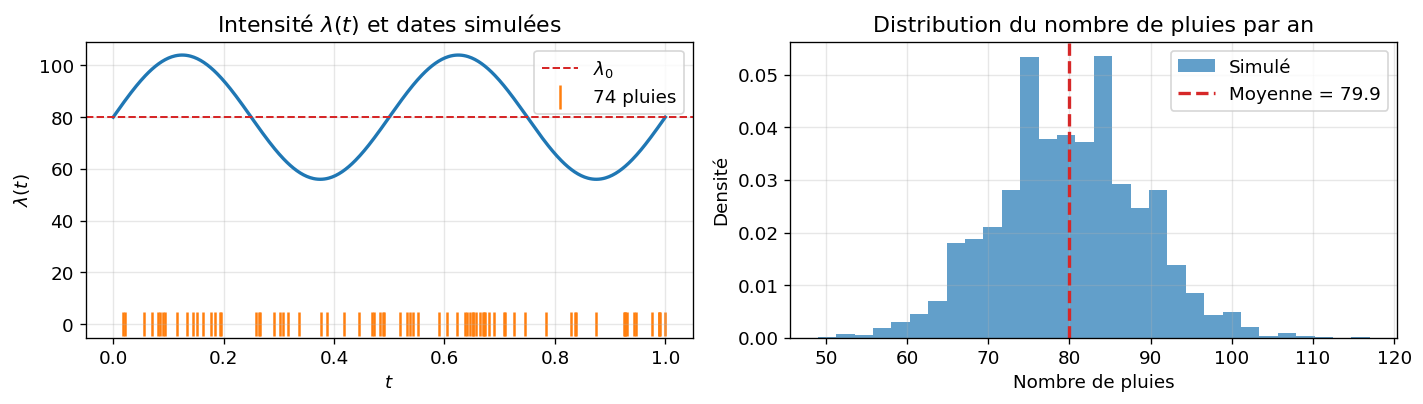

In [35]:
# ── Validation : nombre moyen d'arrivées ≈ λ0 ────────────────────────────────
n_rep = 5_000
comptes = np.array([len(sim_pluies(params, rng)) for _ in range(n_rep)])

print(f"λ0 (valeur théorique) = {params['lambda0']}")
print(f"Nombre moyen simulé   = {comptes.mean():.2f}")
print(f"Variance simulée      = {comptes.var():.2f}  (doit ≈ λ0 = {params['lambda0']})")

# ── Visualisation d'une réalisation ──────────────────────────────────────────
t_ex  = sim_pluies(params, rng)
t_fin = np.linspace(0, 1, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].plot(t_fin, lambda_t(t_fin, params["lambda0"], params["alpha"]), 'C0', lw=2)
axes[0].axhline(params["lambda0"], color='C3', ls='--', lw=1.2, label=r"$\lambda_0$")
axes[0].scatter(t_ex, np.zeros_like(t_ex), marker='|', s=200, color='C1', label=f"{len(t_ex)} pluies")
axes[0].set_xlabel("$t$"); axes[0].set_ylabel(r"$\lambda(t)$")
axes[0].set_title(r"Intensité $\lambda(t)$ et dates simulées")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(comptes, bins=30, density=True, color='C0', alpha=0.7, label="Simulé")
axes[1].axvline(comptes.mean(), color='C3', lw=2, ls='--', label=f"Moyenne = {comptes.mean():.1f}")
axes[1].set_xlabel("Nombre de pluies"); axes[1].set_ylabel("Densité")
axes[1].set_title("Distribution du nombre de pluies par an")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

---

## 4 · Modèle de hauteur d'eau

### 4.1 · Réponse hydrologique

La hauteur d'eau au temps $t$ résulte de la superposition des $n$ pluies passées :

$$H(t) = \sum_{i=1}^{n} I_i \cdot r(t - T_i), \quad r(t) = e^{-v t}\,\mathbf{1}_{t \geq 0}$$

- $r(t)$ est la **réponse impulsionnelle** : l'eau apportée par une pluie se résorbe exponentiellement au taux $v$.
- $H(t)$ est croissante à chaque pluie, décroissante entre deux pluies.

**Remarque :** il suffit d'évaluer $H$ aux instants des pluies pour détecter le maximum, car $H$ est décroissante entre deux pluies et saute en $T_i$. Donc :

$$H_{\max} = \max_{i=1,\ldots,n} H(T_i)$$

In [36]:
def r(t, v):
    """Réponse impulsionnelle : r(t) = exp(-v*t) * 1_{t>=0}."""
    return np.where(t >= 0, np.exp(-v * t), 0.0)


def H_max(Ti, Ii, v):
    """
    Calcule max_i H(T_i) pour un scénario de pluies donné.

    H(T_i) = sum_j  I_j * r(T_i - T_j)

    Args:
        Ti : np.ndarray de forme (n,) — dates des pluies
        Ii : np.ndarray de forme (n,) — intensités
        v  : vitesse de résorption

    Returns:
        float — hauteur maximale
    """
    if len(Ti) == 0:
        return 0.0
    # Matrice des délais : diff[i, j] = T_i - T_j
    diff = Ti[:, None] - Ti[None, :]   # (n, n)
    # H(T_i) = sum_j  I_j * r(T_i - T_j)  — les termes j > i donnent r < 0 → filtrés par r()
    H_vals = (Ii[None, :] * r(diff, v)).sum(axis=1)  # (n,)
    return H_vals.max()

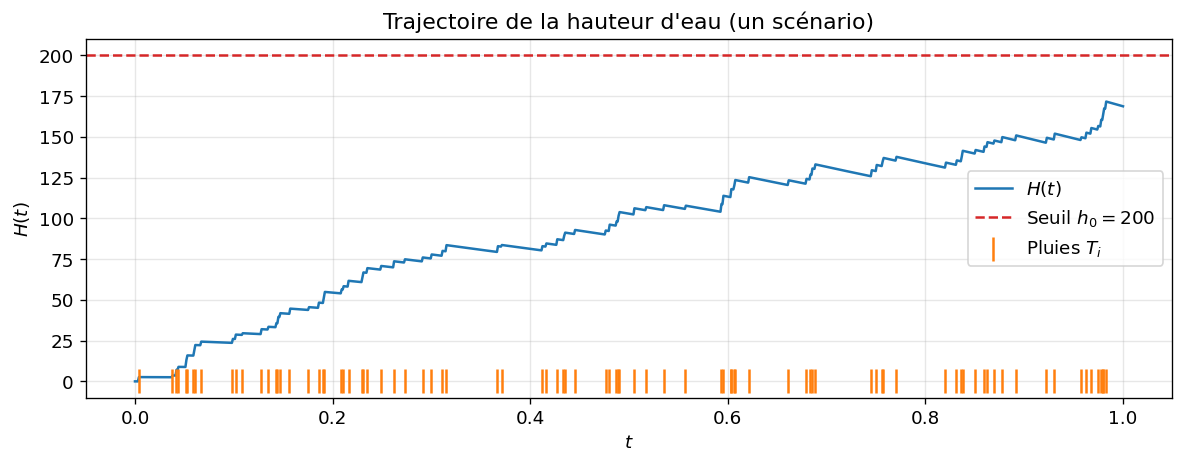

Nombre de pluies  n  = 89
Hauteur maximale Hmax = 171.74  (seuil h0 = 200)


In [37]:
# ── Visualisation d'un scénario de hauteur d'eau ──────────────────────────────
Ti_ex = sim_pluies(params, rng)
Ii_ex = rintensite(len(Ti_ex), params, rng)
v     = params["v"]

t_fin = np.linspace(0, 1, 1000)
H_traj = np.array([
    (Ii_ex * r(t - Ti_ex, v)).sum()
    for t in t_fin
])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_fin, H_traj, 'C0', lw=1.5, label="$H(t)$")
ax.axhline(params["h0"], color='C3', ls='--', lw=1.5, label=f"Seuil $h_0 = {params['h0']}$")
ax.scatter(Ti_ex, np.zeros_like(Ti_ex), marker='|', s=200, color='C1', zorder=5, label="Pluies $T_i$")
ax.set_xlabel("$t$"); ax.set_ylabel("$H(t)$")
ax.set_title("Trajectoire de la hauteur d'eau (un scénario)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Nombre de pluies  n  = {len(Ti_ex)}")
print(f"Hauteur maximale Hmax = {H_max(Ti_ex, Ii_ex, v):.2f}  (seuil h0 = {params['h0']})")

---

## 5 · Estimation Monte Carlo de $p^*$

### 5.1 · Estimateur de Monte Carlo

On cherche à estimer :

$$p^* = \mathbb{P}(H_{\max} > h_0) = \mathbb{E}\bigl[\mathbf{1}_{\{H_{\max} > h_0\}}\bigr]$$

L'**estimateur de Monte Carlo** avec $N$ simulations indépendantes est :

$$\hat{p}^*_N = \frac{1}{N} \sum_{k=1}^{N} \mathbf{1}_{\{H_{\max}^{(k)} > h_0\}}$$

Par le **TCL**, pour $N$ grand :

$$\hat{p}^*_N \approx \mathcal{N}\!\left(p^*,\; \frac{p^*(1-p^*)}{N}\right)$$

L'**intervalle de confiance à 95 %** est :

$$\hat{p}^*_N \pm 1.96\,\sqrt{\frac{\hat{p}^*_N(1 - \hat{p}^*_N)}{N}}$$

In [38]:
def une_inondation(params, rng):
    """
    Simule un scénario annuel et retourne l'indicatrice d'inondation.

    Returns:
        1 si H_max > h0, 0 sinon
    """
    Ti = sim_pluies(params, rng)
    if len(Ti) == 0:
        return 0
    Ii = rintensite(len(Ti), params, rng)
    return int(H_max(Ti, Ii, params["v"]) > params["h0"])


def petoile(n_simul, params, rng):
    """
    Estime p* = P(H_max > h0) par Monte Carlo brut.

    Args:
        n_simul : nombre de simulations
        params  : paramètres du modèle
        rng     : générateur numpy

    Returns:
        dict avec clés : p (estimée), ic_bas, ic_haut, demi_largeur
    """
    indicatrices = np.array([une_inondation(params, rng) for _ in range(n_simul)])
    p            = indicatrices.mean()
    demi         = 1.96 * np.sqrt(p * (1 - p) / n_simul)
    return {"p": p, "ic_bas": p - demi, "ic_haut": p + demi, "demi_largeur": demi}

In [39]:
# ── Estimation de p* ─────────────────────────────────────────────────────────
print("Estimation de p* en cours (Monte Carlo brut)...")
n_simul = 5_000
res = petoile(n_simul, params, rng)

print(f"\n{'─'*45}")
print(f"  Simulations         : {n_simul:,}")
print(f"  p̂*                 : {res['p']:.6f}")
print(f"  IC 95%              : [{res['ic_bas']:.6f},  {res['ic_haut']:.6f}]")
print(f"  Demi-largeur        : {res['demi_largeur']:.6f}")
print(f"{'─'*45}")

Estimation de p* en cours (Monte Carlo brut)...

─────────────────────────────────────────────
  Simulations         : 5,000
  p̂*                 : 0.005000
  IC 95%              : [0.003045,  0.006955]
  Demi-largeur        : 0.001955
─────────────────────────────────────────────


### 5.2 · Convergence de l'estimateur

On trace $\hat{p}^*_N$ en fonction de $N$ pour visualiser la convergence et la réduction de l'intervalle de confiance.

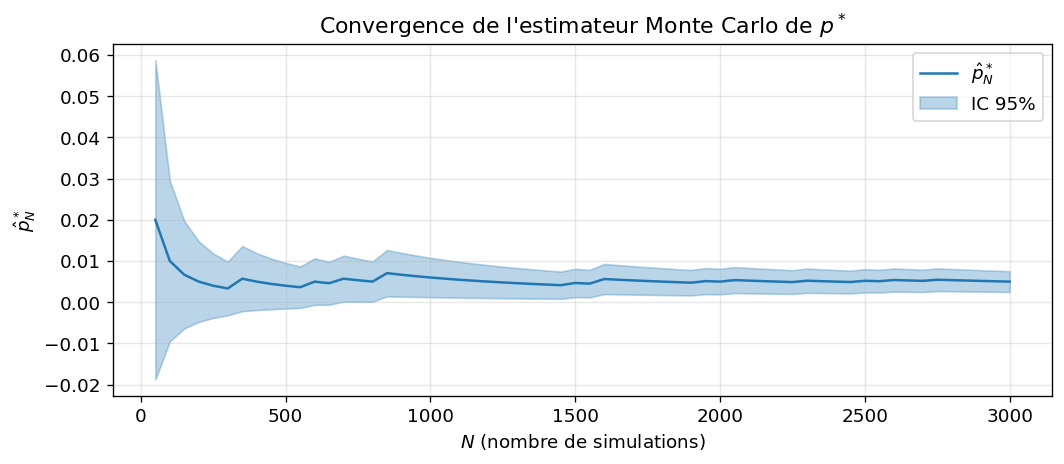

In [40]:
n_total = 3_000
indicatrices_full = np.array([une_inondation(params, rng) for _ in range(n_total)])

N_vals      = np.arange(50, n_total + 1, 50)
p_cumulee   = np.array([indicatrices_full[:n].mean() for n in N_vals])
demi_largeur= 1.96 * np.sqrt(p_cumulee * (1 - p_cumulee) / N_vals)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(N_vals, p_cumulee, 'C0', lw=1.5, label=r"$\hat{p}^*_N$")
ax.fill_between(N_vals,
                p_cumulee - demi_largeur,
                p_cumulee + demi_largeur,
                alpha=0.3, color='C0', label="IC 95%")
ax.set_xlabel("$N$ (nombre de simulations)")
ax.set_ylabel(r"$\hat{p}^*_N$")
ax.set_title("Convergence de l'estimateur Monte Carlo de $p^*$")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---

## 6 · Échantillonnage préférentiel — `petoile_petite`

### 6.1 · Motivation

Lorsque $p^*$ est très petite, le Monte Carlo brut est **inefficace** : la plupart des simulations donnent 0, et la variance relative $\sqrt{(1-p^*)/(N \cdot p^*)}$ explose.  
Pour estimer une probabilité d'ordre $10^{-3}$ avec 1 % de précision relative, il faudrait $N \sim 10^7$ simulations.

**Idée :** remplacer la mesure de probabilité originale $P$ par une mesure $P'$ qui **favorise les inondations**, puis corriger par le poids de Radon-Nikodym.

### 6.2 · Changement de mesure

On remplace le processus de Poisson d'intensité $\lambda(t)$ par un processus d'intensité **augmentée** :

$$\lambda'(t) = \lambda(t) + \delta, \quad \delta > 0$$

Cela génère plus de pluies, donc plus souvent des inondations.

### 6.3 · Poids de Radon-Nikodym

**Provenance : rapport des vraisemblances d'un processus de Poisson.**

La vraisemblance d'un processus de Poisson inhomogène d'intensité $\mu(t)$ sur $[0,1]$, pour $n$ événements aux instants $t_1,\ldots,t_n$, est (densité par rapport à la mesure de référence sur l'espace des configurations de points) :

$$\mathcal{L}(\mu;\,t_1,\ldots,t_n) = \exp\!\left(-\underbrace{\int_0^1 \mu(t)\,dt}_{=\,\Lambda}\right)\prod_{i=1}^n \mu(t_i)$$

Le poids de Radon-Nikodym $dP/dP'$ pour un scénario $(n,\,T_1,\ldots,T_n)$ est le **rapport** de ces deux densités :

$$w_n = \frac{dP}{dP'} = \frac{\mathcal{L}(\lambda;\,T_1,\ldots,T_n)}{\mathcal{L}(\lambda';\,T_1,\ldots,T_n)} = \frac{e^{-\Lambda}\prod_i \lambda(T_i)}{e^{-\Lambda'}\prod_i \lambda'(T_i)} = e^{\,\Lambda'-\Lambda}\prod_{i=1}^n \frac{\lambda(T_i)}{\lambda'(T_i)}$$

avec $\Lambda = \int_0^1\lambda(t)\,dt = \lambda_0$ et $\Lambda' = \int_0^1\lambda'(t)\,dt = \lambda_0 + \delta$, d'où $\Lambda'-\Lambda = \mathbf{+\delta}$.

En substituant $\lambda'(T_i) = \lambda(T_i)+\delta$ :

$$\boxed{w_n = e^{+\delta} \cdot \prod_{i=1}^n \frac{\lambda(T_i)}{\lambda(T_i) + \delta}}$$

> **Erreur fréquente :** écrire $e^{-\delta}$ au lieu de $e^{+\delta}$. Cela arrive en confondant $\int[\lambda-\lambda']\,dt = -\delta$ (mauvais sens) avec $\int[\lambda'-\lambda]\,dt = +\delta$ (correct). Avec $e^{-\delta}$, les poids s'effondrent vers $0$ et l'estimateur donne une probabilité nulle.

**Vérification (non-biais) :** par la formule des fonctionnelles d'un processus de Poisson d'intensité $\lambda'$ (Brémaud 1981), avec $h(t) = \lambda(t)/\lambda'(t)$ :
$$E_{P'}[w_n] = e^{+\delta}\exp\!\left(\int_0^1\lambda'(t)\bigl[h(t)-1\bigr]dt\right) = e^{+\delta}\cdot\exp\!\left(-\int_0^1\delta\,dt\right) = e^{+\delta}\cdot e^{-\delta} = 1\quad\checkmark$$

**Choix de $\delta$ — dégénérescence des poids.** Pour $\delta$ trop grand, le processus $P'$ génère $n \approx \lambda_0+\delta$ événements, et les poids typiques valent :
$$w_{\text{typ}} = e^{+\delta}\cdot\left(\frac{\lambda_0}{\lambda_0+\delta}\right)^{\lambda_0+\delta} = e^{\,\delta\,+\,(\lambda_0+\delta)\ln(\lambda_0/(\lambda_0+\delta))} \xrightarrow{\delta\to+\infty} 0$$
Ce terme tend vers 0, forçant $E_{P'}[w]=1$ à être porté par des réalisations rarissimes — phénomène de **collapse des poids**.  
**Règle pratique :** $\delta \ll \lambda_0$, typiquement $\delta \leq \lambda_0/5$. Pour $\delta=10$, $w_{\text{typ}} \approx e^{-0.6} \approx 0.55$ : valeurs saines.

### 6.4 · Estimateur par importance

$$\hat{p}^*_{\text{IS}} = \frac{1}{N} \sum_{k=1}^{N} \mathbf{1}_{\{H_{\max}^{(k)} > h_0\}} \cdot w_{n_k}$$

C'est un estimateur **sans biais** de $p^*$ sous $P'$, avec une variance potentiellement bien plus faible si $\delta$ est bien choisi.

In [41]:
def sim_pluies_augmente(delta, params, rng):
    """
    Simule les dates d'arrivée selon le processus augmenté d'intensité
    λ'(t) = λ(t) + δ  par thinning.

    Borne supérieure : Λ'_max = λ0*(1+α) + δ  ≤  2*λ0 + δ.

    Returns:
        np.ndarray des dates T_i
    """
    lambda0, alpha = params["lambda0"], params["alpha"]
    Lambda_max_prime = 2 * lambda0 + delta   # borne pour λ'(t)

    dates = []
    t = 0.0
    while True:
        t += rng.exponential(1.0 / Lambda_max_prime)
        if t > 1.0:
            break
        lam_prime_t = lambda_t(t, lambda0, alpha) + delta
        if rng.random() <= lam_prime_t / Lambda_max_prime:
            dates.append(t)
    return np.array(dates)


def poids_RN(Ti, delta, params):
    """
    Calcule le poids de Radon-Nikodym dP/dP' pour un scénario donné.

    Dérivation (rapport de vraisemblances d'un processus de Poisson) :
      w_n = L(λ; T) / L(λ'; T)
          = exp(Λ' - Λ) · ∏ λ(T_i)/λ'(T_i)
          = exp(+δ)     · ∏ λ(T_i)/(λ(T_i)+δ)

    Calcul en log-espace pour éviter overflow (exp(+δ)) et underflow (∏ → 0).
    """
    lambda0, alpha = params["lambda0"], params["alpha"]
    if len(Ti) == 0:
        # produit vide = 1 ; w = e^{+δ}
        return float(np.exp(delta))
    lam   = lambda_t(Ti, lambda0, alpha)                   # λ(T_i)
    log_w = delta + np.sum(np.log(lam / (lam + delta)))    # log w = +δ + Σ log ratio
    return float(np.exp(log_w))


def une_inondation_IS(delta, params, rng):
    """
    Un tirage sous P' avec correction par poids RN.

    Returns:
        float — indicatrice * poids  (contribution à l'estimateur IS)
    """
    Ti = sim_pluies_augmente(delta, params, rng)
    if len(Ti) == 0:
        return 0.0
    Ii = rintensite(len(Ti), params, rng)
    if H_max(Ti, Ii, params["v"]) > params["h0"]:
        return poids_RN(Ti, delta, params)
    return 0.0


def petoile_petite(n_simul, delta, params, rng):
    """
    Estime p* par échantillonnage préférentiel avec intensité λ'= λ + δ.

    Args:
        n_simul : nombre de simulations
        delta   : augmentation constante du taux de Poisson (choisir δ << λ0)
        params  : paramètres du modèle
        rng     : générateur numpy

    Returns:
        dict avec p, variance, ic_bas, ic_haut, demi_largeur
    """
    poids = np.array([une_inondation_IS(delta, params, rng) for _ in range(n_simul)])
    p     = poids.mean()
    var   = poids.var(ddof=1)
    demi  = 1.96 * np.sqrt(var / n_simul)
    return {"p": p, "var": var, "ic_bas": p - demi, "ic_haut": p + demi, "demi_largeur": demi}

In [42]:
# ── Estimation par importance sampling ───────────────────────────────────────
# δ=10 << λ0=80 : poids typique ≈ exp(10 + 90·ln(80/90)) = exp(-0.6) ≈ 0.55
# Avec δ=70 (>> λ0), les poids s'effondrent vers ~exp(-24) ≈ 10⁻¹¹ :
#   dégénérescence garantie, estimateur ≈ 0 même avec la formule correcte.
delta   = 10
n_simul = 5_000

print(f"Estimation de p* par importance sampling (δ = {delta})...")
res_IS = petoile_petite(n_simul, delta, params, rng)

print(f"\n{'─'*50}")
print(f"  δ (augmentation taux)  : {delta}")
print(f"  Simulations            : {n_simul:,}")
print(f"  p̂* (IS)               : {res_IS['p']:.6f}")
print(f"  IC 95%                 : [{res_IS['ic_bas']:.6f},  {res_IS['ic_haut']:.6f}]")
print(f"  Demi-largeur           : {res_IS['demi_largeur']:.6f}")
print(f"  Variance estimée       : {res_IS['var']:.6e}")
print(f"{'─'*50}")

Estimation de p* par importance sampling (δ = 10)...

──────────────────────────────────────────────────
  δ (augmentation taux)  : 10
  Simulations            : 5,000
  p̂* (IS)               : 0.005880
  IC 95%                 : [0.005164,  0.006597]
  Demi-largeur           : 0.000716
  Variance estimée       : 6.680573e-04
──────────────────────────────────────────────────


### 6.5 · Comparaison Monte Carlo brut vs Importance Sampling

On compare les deux méthodes en termes de **précision relative** (demi-largeur / estimée) pour un même budget de calcul.

Méthode                   Moyenne          Std     CV (%)
─────────────────────────────────────────────────────────
Monte Carlo brut          0.00687      0.00360      52.5%
Importance sampling       0.00613      0.00117      19.1%


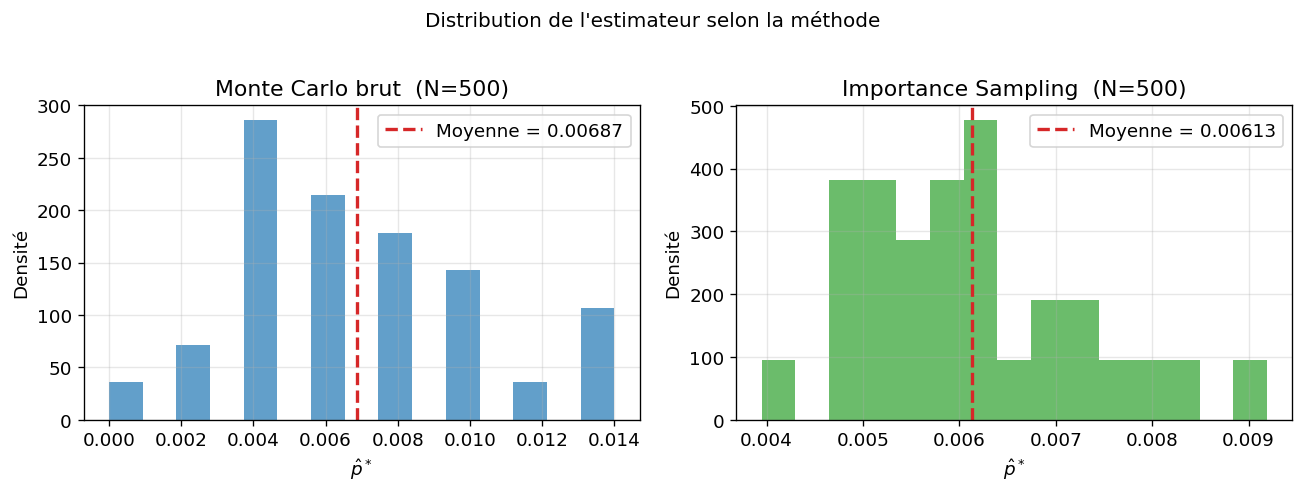

In [43]:
n_rep    = 30   # répétitions indépendantes pour chaque méthode
n_budget = 500  # budget par répétition

p_mc = np.array([petoile(n_budget, params, rng)["p"]         for _ in range(n_rep)])
p_is = np.array([petoile_petite(n_budget, delta, params, rng)["p"] for _ in range(n_rep)])

print(f"{'Méthode':<22} {'Moyenne':>10} {'Std':>12} {'CV (%)':>10}")
print("─" * 57)
for nom, echant in [("Monte Carlo brut", p_mc), ("Importance sampling", p_is)]:
    mu  = echant.mean()
    sig = echant.std()
    cv  = sig / mu * 100 if mu > 0 else float("nan")
    print(f"{nom:<22} {mu:>10.5f} {sig:>12.5f} {cv:>9.1f}%")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, echant, nom, couleur in [
    (axes[0], p_mc, "Monte Carlo brut",    'C0'),
    (axes[1], p_is, "Importance Sampling",  'C2'),
]:
    ax.hist(echant, bins=15, color=couleur, alpha=0.7, density=True)
    ax.axvline(echant.mean(), color='C3', lw=2, ls='--', label=f"Moyenne = {echant.mean():.5f}")
    ax.set_xlabel(r"$\hat{p}^*$"); ax.set_ylabel("Densité")
    ax.set_title(nom + f"  (N={n_budget})"); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Distribution de l'estimateur selon la méthode", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

---

## 7 · Variable de contrôle — réduction de variance

### 7.1 · Principe général

L'estimateur Monte Carlo $\hat{p}^*_N$ a variance $p^*(1-p^*)/N$. On peut la réduire **sans changer la loi de simulation** en soustrayant un terme de **variable de contrôle** (VC).

Soit $C$ une v.a. calculée lors de chaque simulation, telle que $E[C]$ est **connu exactement**. L'estimateur corrigé est :

$$\hat{p}^*_{\mathrm{VC}} = \bar{Z} - b\bigl(\bar{C} - E[C]\bigr), \qquad Z_k = \mathbf{1}_{H_{\max}^{(k)} > h_0}$$

**Sans biais :** $E[\hat{p}^*_{\mathrm{VC}}] = p^* - b\,(E[C] - E[C]) = p^*$ pour tout $b$.

**Variance :** en développant et en minimisant en $b$ :

$$\mathrm{Var}[\hat{p}^*_{\mathrm{VC}}] = \frac{\mathrm{Var}[Z] + b^2\,\mathrm{Var}[C] - 2b\,\mathrm{Cov}(Z,C)}{N}$$

Le coefficient optimal $b^* = \mathrm{Cov}(Z,C)/\mathrm{Var}(C)$ minimise la variance, et donne :

$$\boxed{\mathrm{Var}[\hat{p}^*_{\mathrm{VC}}] = \frac{\mathrm{Var}[Z]\,(1-\rho^2)}{N}}$$

où $\rho = \mathrm{Corr}(Z,C)$. **Gain :** facteur $1/(1-\rho^2)$ sur $N$, soit une réduction de $\rho^2 \times 100\,\%$ de la variance.

### 7.2 · Choix de $C$ : intensité totale des pluies

On choisit $C = \displaystyle\sum_{i=1}^{N_T} I_i$ (somme des intensités de toutes les pluies de l'année).

**Pourquoi ?** $C$ et $H_{\max}$ sont positivement corrélés car $H(t) = \sum_i I_i\,e^{-v(t-T_i)} \leq \sum_i I_i = C$, et les grandes valeurs de $C$ favorisent un $H_{\max}$ élevé. Donc $\mathrm{Cov}(Z, C) > 0$.

**Calcul analytique de $E[C]$ via la formule de Wald :**

Conditionnellement à $N_T$, les $I_i$ sont i.i.d. et indépendants de $N_T$. Par la **formule de Wald** :

$$E[C] = E\!\left[\sum_{i=1}^{N_T} I_i\right] = E[N_T]\cdot E[I] = \lambda_0\cdot\mu_I$$

Les deux quantités sont connues :
- $E[N_T] = \lambda_0$ (car $N_T \sim \mathcal{P}(\lambda_0)$)
- $\mu_I = E[I] = \displaystyle\int_0^{+\infty} x\,f_I(x)\,dx = c_I\int_0^{+\infty}\frac{x}{m+|x-x_0|^\eta}\,dx \quad$ (intégrale numérique)

### 7.3 · Estimation pratique de $b^*$

Le coefficient $b^* = \mathrm{Cov}(Z,C)/\mathrm{Var}(C)$ est inconnu. On l'estime sur le **même** échantillon de $N$ simulations :

$$\hat{b}^* = \frac{\frac{1}{N-1}\sum_k(Z_k-\bar{Z})(C_k-\bar{C})}{\frac{1}{N-1}\sum_k(C_k-\bar{C})^2}$$

L'estimation de $b^*$ introduit un biais d'ordre $O(1/N)$, négligeable pour $N$ grand.

In [44]:
def mu_I_analytique(params):
    """E[I] = c_I * ∫_0^∞ x / (m + |x-x0|^eta) dx  (intégrale numérique)."""
    C_I = calc_c_I(params)
    m, x0, eta = params["m"], params["x0"], params["eta"]
    val, _ = sci_int.quad(lambda x: x / (m + np.abs(x - x0)**eta), 0, np.inf)
    return C_I * val


def une_simulation_VC(params, rng):
    """
    Un tirage Monte Carlo retournant (Z_k, C_k).
      Z_k = 1_{H_max > h0}   indicatrice d'inondation
      C_k = Σ I_i             variable de contrôle (intensité totale)
    """
    Ti = sim_pluies(params, rng)
    if len(Ti) == 0:
        return 0, 0.0
    Ii = rintensite(len(Ti), params, rng)
    z  = int(H_max(Ti, Ii, params["v"]) > params["h0"])
    c  = float(Ii.sum())
    return z, c


def petoile_VC(n_simul, params, rng):
    """
    Estime p* = P(H_max > h0) par variable de contrôle C = ΣI_i.

    Formule de Wald : E[C] = λ0 · E[I] = λ0 · μ_I   (analytiquement connu)
    Coefficient optimal estimé : b_hat = Cov(Z,C) / Var(C)
    Estimateur : p_VC = mean(Z) - b_hat * (mean(C) - E[C])
    Réduction de variance : facteur (1 - ρ²)

    Returns:
        dict avec p, var, ic_bas, ic_haut, demi_largeur, b_opt, rho, reduction_pct
    """
    mu_I_val = mu_I_analytique(params)
    E_C      = params["lambda0"] * mu_I_val    # Wald : E[C] = λ0 · E[I]

    res = [une_simulation_VC(params, rng) for _ in range(n_simul)]
    Z   = np.array([r[0] for r in res], dtype=float)
    C   = np.array([r[1] for r in res])

    # Coefficient optimal estimé sur l'échantillon
    b_hat = np.cov(Z, C)[0, 1] / C.var(ddof=1)

    # Estimateur corrigé par variable de contrôle
    Z_corr = Z - b_hat * (C - E_C)
    p      = Z_corr.mean()
    var_VC = Z_corr.var(ddof=1)
    demi   = 1.96 * np.sqrt(var_VC / n_simul)
    rho    = float(np.corrcoef(Z, C)[0, 1])

    return {
        "p"            : p,
        "var"          : var_VC,
        "ic_bas"       : p - demi,
        "ic_haut"      : p + demi,
        "demi_largeur" : demi,
        "b_opt"        : b_hat,
        "mu_I"         : mu_I_val,
        "E_C"          : E_C,
        "rho"          : rho,
        "reduction_pct": (1.0 - rho**2) * 100.0,
    }

In [45]:
# ── Calcul analytique de μ_I et E[C] ─────────────────────────────────────────
mu_I_val = mu_I_analytique(params)
print(f"μ_I = E[I]        = {mu_I_val:.6f}")
print(f"E[C] = λ0 · μ_I  = {params['lambda0']} × {mu_I_val:.6f} = {params['lambda0']*mu_I_val:.4f}")

# ── Estimation par variable de contrôle ──────────────────────────────────────
n_simul = 5_000
print(f"\nEstimation de p* par variable de contrôle (N = {n_simul:,})...")
res_VC = petoile_VC(n_simul, params, rng)

print(f"\n{'─'*55}")
print(f"  Simulations           : {n_simul:,}")
print(f"  p̂* (VC)              : {res_VC['p']:.6f}")
print(f"  IC 95%                : [{res_VC['ic_bas']:.6f},  {res_VC['ic_haut']:.6f}]")
print(f"  Demi-largeur          : {res_VC['demi_largeur']:.6f}")
print(f"  Coefficient b̂*       : {res_VC['b_opt']:.6f}")
print(f"  Corrélation ρ̂(Z, C) : {res_VC['rho']:.4f}")
print(f"  Réduction de variance : {res_VC['reduction_pct']:.1f}%")
print(f"{'─'*55}")

μ_I = E[I]        = 3.010048
E[C] = λ0 · μ_I  = 80 × 3.010048 = 240.8039

Estimation de p* par variable de contrôle (N = 5,000)...

───────────────────────────────────────────────────────
  Simulations           : 5,000
  p̂* (VC)              : 0.006639
  IC 95%                : [0.004457,  0.008821]
  Demi-largeur          : 0.002182
  Coefficient b̂*       : 0.000675
  Corrélation ρ̂(Z, C) : 0.2344
  Réduction de variance : 94.5%
───────────────────────────────────────────────────────


c:\Users\diaba\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\diaba\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Méthode                         Moyenne        Std    CV (%)
────────────────────────────────────────────────────────────
MC brut                         0.00667    0.00348     52.2%
Imp. Sampling (δ=10)            0.00605    0.00126     20.8%
Variable contrôle (ΣI_i)        0.00522    0.00274     52.5%


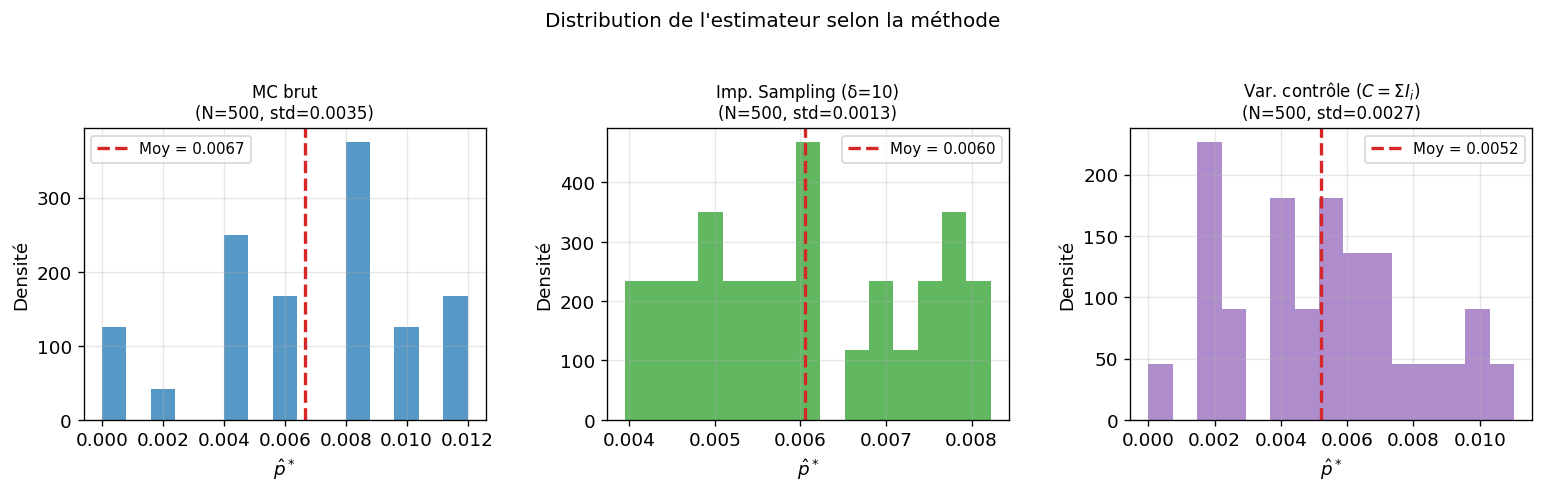

In [46]:
# ── Comparaison des trois méthodes ───────────────────────────────────────────
n_rep    = 30
n_budget = 500

p_mc = np.array([petoile(n_budget, params, rng)["p"]              for _ in range(n_rep)])
p_is = np.array([petoile_petite(n_budget, delta, params, rng)["p"] for _ in range(n_rep)])
p_vc = np.array([petoile_VC(n_budget, params, rng)["p"]            for _ in range(n_rep)])

print(f"{'Méthode':<28} {'Moyenne':>10} {'Std':>10} {'CV (%)':>9}")
print("─" * 60)
for nom, ech in [
    ("MC brut",                    p_mc),
    (f"Imp. Sampling (δ={delta})", p_is),
    ("Variable contrôle (ΣI_i)",   p_vc),
]:
    mu  = ech.mean()
    sig = ech.std()
    cv  = sig / mu * 100 if mu > 1e-10 else float("nan")
    print(f"{nom:<28} {mu:>10.5f} {sig:>10.5f} {cv:>8.1f}%")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, ech, nom, col in [
    (axes[0], p_mc, "MC brut",                          'C0'),
    (axes[1], p_is, f"Imp. Sampling (δ={delta})",        'C2'),
    (axes[2], p_vc, r"Var. contrôle ($C=\Sigma I_i$)",  'C4'),
]:
    ax.hist(ech, bins=15, color=col, alpha=0.75, density=True)
    ax.axvline(ech.mean(), color='C3', lw=2, ls='--',
               label=f"Moy = {ech.mean():.4f}")
    ax.set_xlabel(r"$\hat{p}^*$"); ax.set_ylabel("Densité")
    ax.set_title(f"{nom}\n(N={n_budget}, std={ech.std():.4f})", fontsize=10)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle("Distribution de l'estimateur selon la méthode", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

---

## 8 · Bilan

| Étape | Méthode | Résultat |
|---|---|---|
| Simulation $\pi_I$ | Mélange rejet (uniforme + Cauchy) | $O(n)$ |
| Dates des pluies | Thinning de Lewis-Shedler | $O(\lambda_0)$ par an |
| Hauteur $H_{\max}$ | Calcul matriciel $(n \times n)$ | $O(n^2)$ |
| Estimation $p^*$ (MC) | Monte Carlo brut | IC $\propto 1/\sqrt{N}$ |
| Estimation $p^*$ (IS) | Importance sampling ($\lambda' = \lambda + \delta$, $\delta\ll\lambda_0$) | Variance réduite si $\delta$ bien calibré |
| Estimation $p^*$ (VC) | Variable de contrôle $C = \sum I_i$ | Variance $\times (1 - \rho^2)$ |

**Points clés sur l'importance sampling :**
- La formule exacte du poids RN est $w_n = e^{+\delta}\cdot\prod_i \lambda(T_i)/(\lambda(T_i)+\delta)$ — le signe $+$ provient du rapport de vraisemblances $e^{\Lambda'-\Lambda} = e^{+\delta}$ (et **non** $e^{-\delta}$).
- Pour $\delta$ trop grand, les poids dégénèrent ($w_{\text{typ}}\to 0$) et l'estimateur vaut numériquement 0. Garder $\delta \leq \lambda_0/5$.

**Points clés sur la variable de contrôle :**
- $C = \sum I_i$ est corrélée positivement avec $Z = \mathbf{1}_{H_{\max}>h_0}$ car une pluie intense fait monter $H_{\max}$.
- $E[C] = \lambda_0\,\mu_I$ est calculé **exactement** par la formule de Wald ($N_T \perp I_i$, $N_T\sim\mathcal{P}(\lambda_0)$).
- Réduction de variance : $1 - \hat{\rho}^2$, mesurable directement sur l'échantillon.